In [132]:
import seaborn
import pandas 
import base
import observer
import attrib
import stores
import numpy
import geopandas
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import calendar


In [134]:
data_store_path = "E:\\Bayer\\bay.18\\models\\xKnowRes230822\\run\\TestRun_xKnowRes\\mcs\\X3UDQO3DQEVSMR85MU\\store"   

  
spatial_data_output_a = "f:\\ConcentrationInFruits.shp"
spatial_data_output_b = "f:\\ConcentrationInStems.shp"
spatial_data_output_c = "f:\\ConcentrationInLeaves.shp"
spatial_data_output_d = "f:\\ConcentrationInRoots.shp"

name_of_dataset_a = "ConcentrationInFruits" 
name_of_dataset_b = "ConcentrationInStems" 
name_of_dataset_c= "ConcentrationInLeaves" 
name_of_dataset_d = "ConcentrationInRoots"  

units = "mg/kg"


In [146]:
concentrations = base.Input(
    "ConcentrationInFruits",
    (attrib.Class(numpy.ndarray), attrib.Unit(units), attrib.Scales("space/base_geometry, time/day")),
    observer.ConsoleObserver(print_output=True),
    base.Output(
        "Dpu/"+name_of_dataset_a,
        stores.X3dfStore(data_store_path, mode="r")
    )
).read()

NOTE  Input ConcentrationInFruits is missing a detailed description

OK    ConcentrationInFruits:ClassChecker:GetValues

      Values are of type <class 'numpy.ndarray'>

OK    ConcentrationInFruits:UnitChecker:GetValues

      Values have unit mg/kg

OK    ConcentrationInFruits:ScalesChecker:GetValues

      Values have scales space/base_geometry, time/day



In [4]:
concentrationsb = base.Input(
    name_of_dataset_b,
    (attrib.Class(numpy.ndarray), attrib.Unit(units), attrib.Scales("space/base_geometry, time/day")),
    observer.ConsoleObserver(print_output=True),
    base.Output(
        "Dpu/"+name_of_dataset_b,
        stores.X3dfStore(data_store_path, mode="r")
    )
).read()

NOTE  Input ConcentrationInStems is missing a detailed description

OK    ConcentrationInStems:ClassChecker:GetValues

      Values are of type <class 'numpy.ndarray'>

OK    ConcentrationInStems:UnitChecker:GetValues

      Values have unit mg/kg

OK    ConcentrationInStems:ScalesChecker:GetValues

      Values have scales space/base_geometry, time/day



In [5]:
concentrationsc = base.Input(
    name_of_dataset_c,
    (attrib.Class(numpy.ndarray), attrib.Unit(units), attrib.Scales("space/base_geometry, time/day")),
    observer.ConsoleObserver(print_output=True),
    base.Output(
        "Dpu/"+name_of_dataset_c,
        stores.X3dfStore(data_store_path, mode="r")
    )
).read()

NOTE  Input ConcentrationInLeaves is missing a detailed description

OK    ConcentrationInLeaves:ClassChecker:GetValues

      Values are of type <class 'numpy.ndarray'>

OK    ConcentrationInLeaves:UnitChecker:GetValues

      Values have unit mg/kg

OK    ConcentrationInLeaves:ScalesChecker:GetValues

      Values have scales space/base_geometry, time/day



In [6]:
concentrationsd = base.Input(
    name_of_dataset_d,
    (attrib.Class(numpy.ndarray), attrib.Unit(units), attrib.Scales("space/base_geometry, time/day")),
    observer.ConsoleObserver(print_output=True),
    base.Output(
        "Dpu/"+name_of_dataset_d,
        stores.X3dfStore(data_store_path, mode="r")
    )
).read()

NOTE  Input ConcentrationInRoots is missing a detailed description

OK    ConcentrationInRoots:ClassChecker:GetValues

      Values are of type <class 'numpy.ndarray'>

OK    ConcentrationInRoots:UnitChecker:GetValues

      Values have unit mg/kg

OK    ConcentrationInRoots:ScalesChecker:GetValues

      Values have scales space/base_geometry, time/day



In [7]:
field_geometries = geopandas.GeoDataFrame(
    geometry=geopandas.GeoSeries.from_wkb(concentrations.geometries[0].get_values()),
    crs="EPSG:3857"
).to_crs(crs="EPSG:4326")
field_geometries["field_idx"] = field_geometries.reset_index().index

In [8]:
field_geometriesb = geopandas.GeoDataFrame(
    geometry=geopandas.GeoSeries.from_wkb(concentrationsb.geometries[0].get_values()),
    crs="EPSG:3857"
).to_crs(crs="EPSG:4326")
field_geometriesb["field_idx"] = field_geometriesb.reset_index().index

In [9]:
field_geometriesc = geopandas.GeoDataFrame(
    geometry=geopandas.GeoSeries.from_wkb(concentrationsc.geometries[0].get_values()),
    crs="EPSG:3857"
).to_crs(crs="EPSG:4326")
field_geometriesc["field_idx"] = field_geometriesc.reset_index().index

In [10]:
field_geometriesd = geopandas.GeoDataFrame(
    geometry=geopandas.GeoSeries.from_wkb(concentrationsd.geometries[0].get_values()),
    crs="EPSG:3857"
).to_crs(crs="EPSG:4326")
field_geometriesd["field_idx"] = field_geometriesd.reset_index().index

In [11]:
geo_df = field_geometries.merge(
    pandas.DataFrame(
       numpy.c_[
           numpy.argwhere(concentrations.values > 0),
           concentrations.values[concentrations.values > 0]
       ],
       columns=("field_idx", "time_idx", "concentration")
    ),
    on="field_idx"
)

In [12]:
geo_dfb = field_geometries.merge(
    pandas.DataFrame(
       numpy.c_[
           numpy.argwhere(concentrationsb.values > 0),
           concentrationsb.values[concentrationsb.values > 0]
       ],
       columns=("field_idx", "time_idx", "concentration")
    ),
    on="field_idx"
)

In [13]:
geo_dfc = field_geometries.merge(
    pandas.DataFrame(
       numpy.c_[
           numpy.argwhere(concentrationsc.values > 0),
           concentrationsc.values[concentrationsc.values > 0]
       ],
       columns=("field_idx", "time_idx", "concentration")
    ),
    on="field_idx"
)

In [14]:
geo_dfd = field_geometries.merge(
    pandas.DataFrame(
       numpy.c_[
           numpy.argwhere(concentrationsd.values > 0),
           concentrationsd.values[concentrationsd.values > 0]
       ],
       columns=("field_idx", "time_idx", "concentration")
    ),
    on="field_idx"
)

In [15]:
geo_df["date"] = pandas.to_datetime(concentrations.offsets[1]) + pandas.to_timedelta(geo_df["time_idx"], unit="D")
geo_df["date"] = geo_df["date"].dt.strftime("%Y-%m-%d")
geo_df.to_file(spatial_data_output_a)

C:\Users\JillianLaRoe\AppData\Local\Temp\ipykernel_34804\3786952187.py:3: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  geo_df.to_file(spatial_data_output_a)


In [16]:
geo_dfb["date"] = pandas.to_datetime(concentrationsb.offsets[1]) + pandas.to_timedelta(geo_dfb["time_idx"], unit="D")
geo_dfb["date"] = geo_dfb["date"].dt.strftime("%Y-%m-%d")
geo_dfb.to_file(spatial_data_output_b)

C:\Users\JillianLaRoe\AppData\Local\Temp\ipykernel_34804\1734252976.py:3: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  geo_dfb.to_file(spatial_data_output_b)


In [17]:
geo_dfc["date"] = pandas.to_datetime(concentrationsc.offsets[1]) + pandas.to_timedelta(geo_dfc["time_idx"], unit="D")
geo_dfc["date"] = geo_dfc["date"].dt.strftime("%Y-%m-%d")
geo_dfc.to_file(spatial_data_output_c)

C:\Users\JillianLaRoe\AppData\Local\Temp\ipykernel_34804\1685304412.py:3: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  geo_dfc.to_file(spatial_data_output_c)


In [18]:
geo_dfd["date"] = pandas.to_datetime(concentrationsd.offsets[1]) + pandas.to_timedelta(geo_dfd["time_idx"], unit="D")
geo_dfd["date"] = geo_dfd["date"].dt.strftime("%Y-%m-%d")
geo_dfd.to_file(spatial_data_output_d)

C:\Users\JillianLaRoe\AppData\Local\Temp\ipykernel_34804\3018069810.py:3: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  geo_dfd.to_file(spatial_data_output_d)


In [135]:
geo_df = geopandas.read_file(spatial_data_output_a)
geo_dfb = geopandas.read_file(spatial_data_output_b)
geo_dfc = geopandas.read_file(spatial_data_output_c)
geo_dfd = geopandas.read_file(spatial_data_output_d)

In [20]:
#print(geo_dfc)

In [136]:
median_concentration = geo_df.groupby('date')['concentrat'].median()
percentile_5 = geo_df.groupby('date')['concentrat'].quantile(0.05)
percentile_95 = geo_df.groupby('date')['concentrat'].quantile(0.95)
unique_datesx = pandas.DataFrame(geo_df['date'].unique(),columns=['date'])

geo_df['date'] = pandas.to_datetime(geo_df['date'])
unique_dates_a = geo_df['date'].dt.to_period('D').unique().to_timestamp()
first_day_of_each_month_a = [date for date in unique_dates_a if date.day == 1]

In [123]:
#median_concentrationb = geo_dfb.groupby('date')['concentrat'].median()

# Convert the 'time' column to datetime format
#geo_dfb['date'] = pandas.to_datetime(geo_dfb['date'])
#unique_dates_b = geo_dfb['date'].dt.to_period('D').unique().to_timestamp()
#print(median_concentration_indexb)
#first_day_of_each_month_b = [date for date in unique_dates_b if date.day == 1]
#print(first_day_of_each_month)

In [137]:
test3 = pandas.concat([median_concentration.reset_index(drop=True), unique_datesx.reset_index(drop=True)], axis=1)
#print(test3)

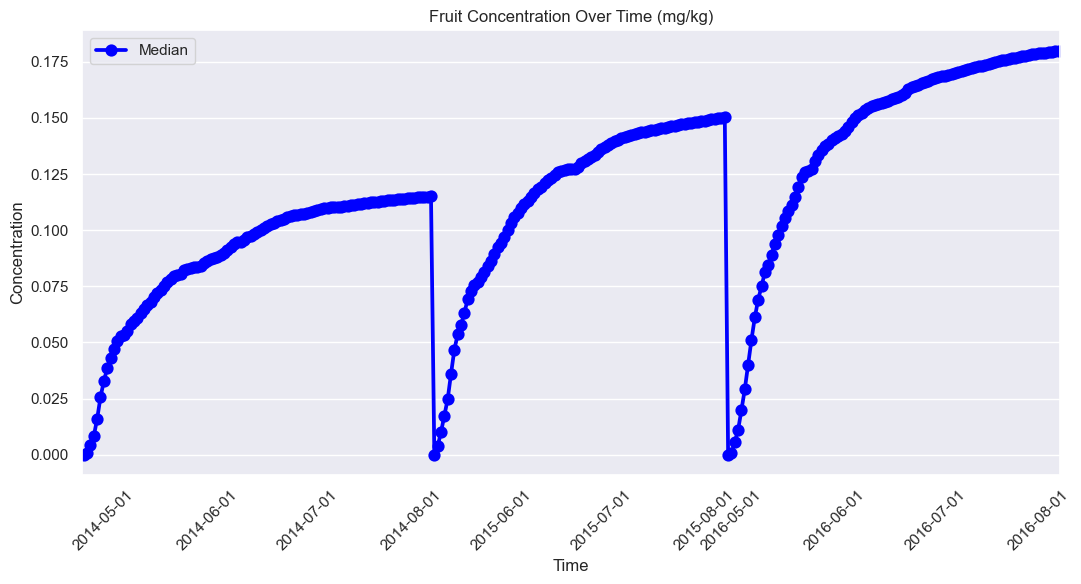

In [138]:
plt.figure(figsize=(11, 6))
seaborn.set_theme(style="darkgrid")
seaborn.pointplot(data=test3, x="date", y="concentrat", color='blue', label='Median')
plt.xlabel('Time')
plt.ylabel('Concentration')
plt.title('Fruit Concentration Over Time (mg/kg)')
#plt.gca().xaxis.set_major_locator(mdates.MonthLocator(1))
#plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks([date.strftime('%Y-%m-%d') for date in first_day_of_each_month_a], rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

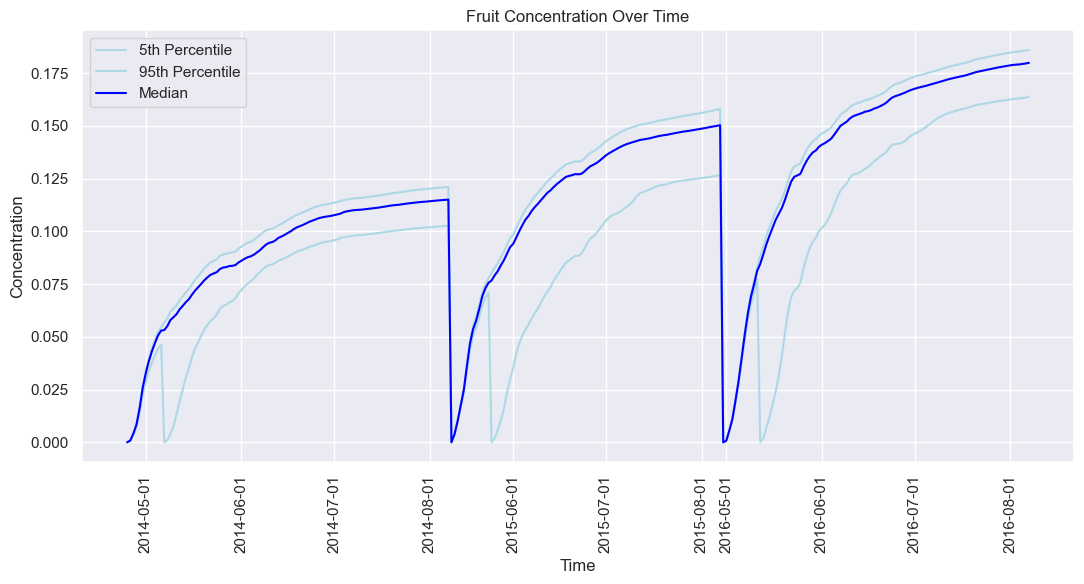

In [139]:
plt.figure(figsize=(11, 6))
seaborn.set_theme(style="darkgrid")
seaborn.lineplot(data=percentile_5, color='lightblue', label='5th Percentile')
seaborn.lineplot(data=percentile_95, color='lightblue', label='95th Percentile')
seaborn.lineplot(data=median_concentration, color='blue', label='Median')
plt.xlabel('Time')
plt.ylabel('Concentration')
plt.title('Fruit Concentration Over Time')
#plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
#plt.gca().xaxis.set_major_locator(mdates.MonthLocator(1))
plt.xticks([date.strftime('%Y-%m-%d') for date in first_day_of_each_month_a], rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

In [140]:
seaborn.set_theme(style="whitegrid")

test3['date'] = pandas.to_datetime(test3['date'])
test3['day'] = test3['date'].dt.day
test3['month'] = test3['date'].dt.month
test3['year'] = test3['date'].dt.year


test3['month'] = test3['month'].apply(lambda x: calendar.month_abbr[x])
#print(test3)

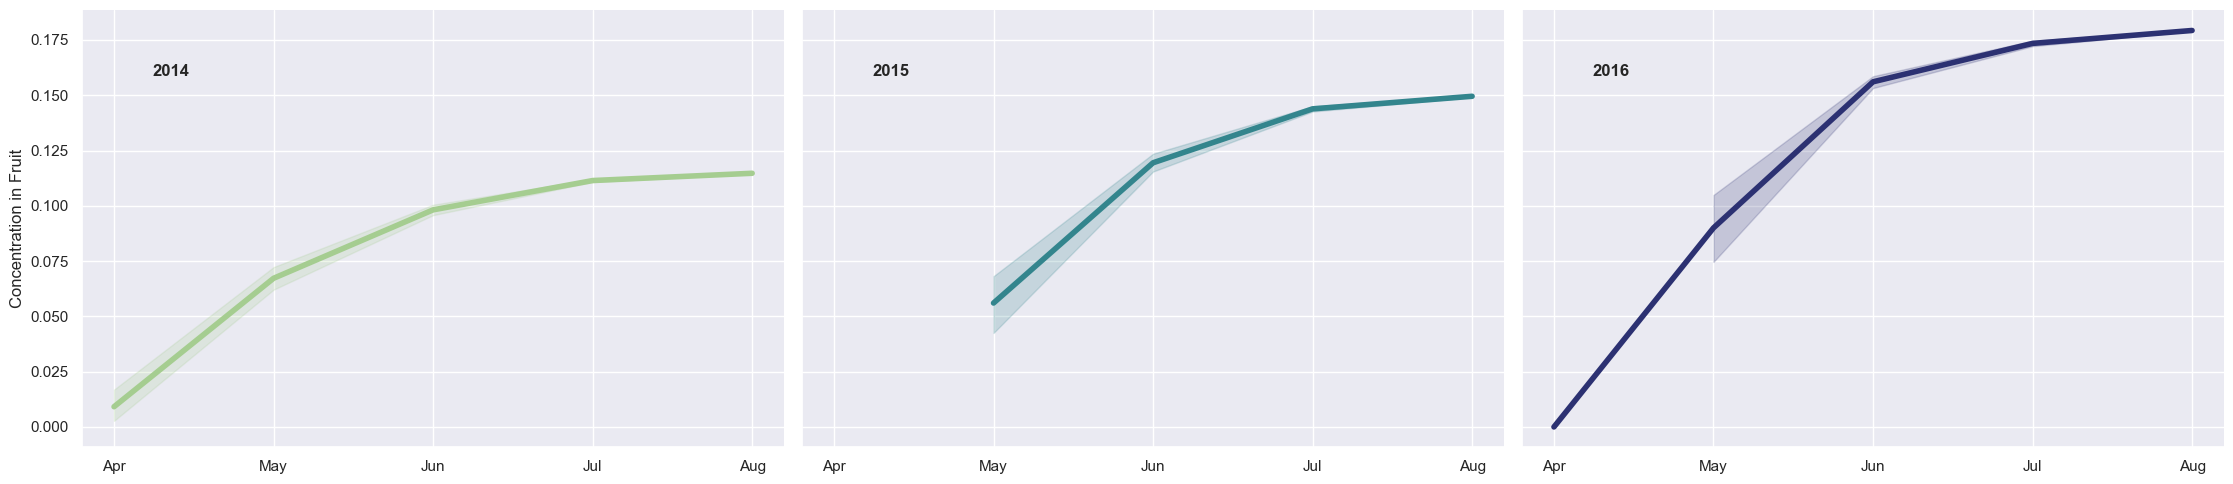

In [141]:
seaborn.set_theme(style="darkgrid")


# Plot each year's time series in its own facet
g = seaborn.relplot(
    data=test3,
    x="month", y="concentrat", col="year", hue="year",
    kind="line", palette="crest", linewidth=4, zorder=5,
    col_wrap=3, height=5, aspect=1.5, legend=False,
)

for year, ax in g.axes_dict.items():

    # Add the title as an annotation within the plot
    ax.text(.1, .85, year, transform=ax.transAxes, fontweight="bold")

g.set_titles("")
g.set_axis_labels("", "Concentration in Fruit")
g.tight_layout()

In [164]:
geo_df = geopandas.read_file(spatial_data_output_a)
geo_dfb = geopandas.read_file(spatial_data_output_b)

date1 = '2014-08-07'
date2 = '2015-08-07'
new_concentration = 0
geo_df.loc[geo_df['date'] == date1, 'concentrat'] = new_concentration
geo_df.loc[geo_df['date'] == date2, 'concentrat'] = new_concentration

geo_dfb.loc[geo_dfb['date'] == date1, 'concentrat'] = new_concentration
geo_dfb.loc[geo_dfb['date'] == date2, 'concentrat'] = new_concentration




median_concentrationa = geo_df.groupby('date')['concentrat'].median()
percentile_5a = geo_df.groupby('date')['concentrat'].quantile(0.05)
percentile_95a = geo_df.groupby('date')['concentrat'].quantile(0.95)
#unique_datesa = pandas.DataFrame(geo_df['date'].unique(),columns=['date'])
#print(unique_datesa)

median_concentrationb = geo_dfb.groupby('date')['concentrat'].median()
percentile_5b = geo_dfb.groupby('date')['concentrat'].quantile(0.05)
percentile_95b = geo_dfb.groupby('date')['concentrat'].quantile(0.95)

geo_dfb['date'] = pandas.to_datetime(geo_dfb['date'])
unique_dates_b = geo_dfb['date'].dt.to_period('D').unique().to_timestamp()
first_day_of_each_month_b = [date for date in unique_dates_b if date.day == 1]

median_concentrationc = geo_dfc.groupby('date')['concentrat'].median()
percentile_5c = geo_dfc.groupby('date')['concentrat'].quantile(0.05)
percentile_95c = geo_dfc.groupby('date')['concentrat'].quantile(0.95)

median_concentrationd = geo_dfd.groupby('date')['concentrat'].median()
percentile_5d = geo_dfd.groupby('date')['concentrat'].quantile(0.05)
percentile_95d = geo_dfd.groupby('date')['concentrat'].quantile(0.95)


In [155]:
#type(geo_df)

geopandas.geodataframe.GeoDataFrame

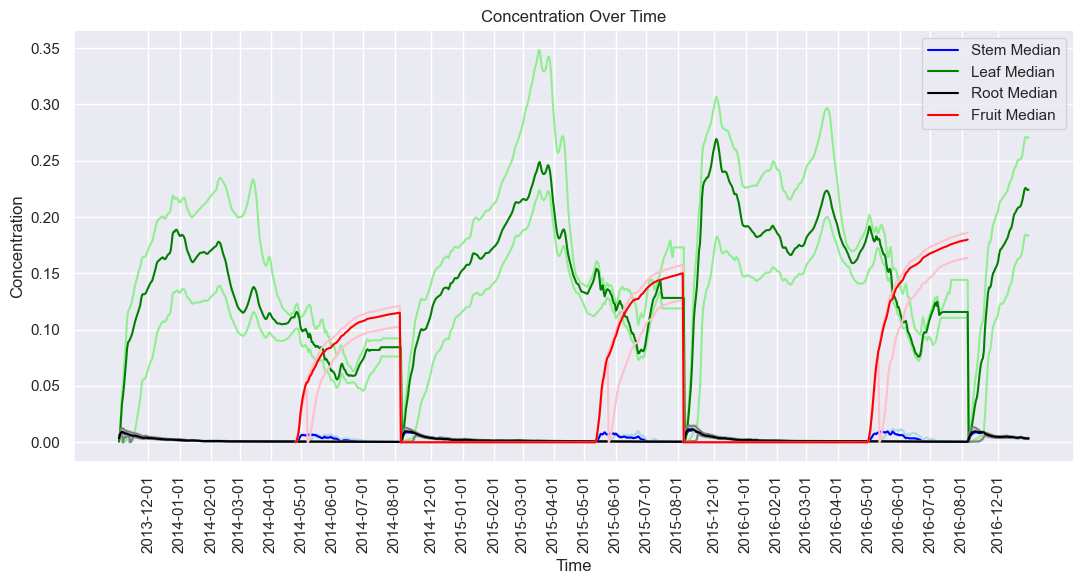

In [165]:
plt.figure(figsize=(11, 6))
seaborn.set_theme(style="darkgrid")
seaborn.lineplot(data=percentile_5b, color='lightblue')#, label='Stem 5th Percentile')
seaborn.lineplot(data=percentile_95b, color='lightblue')#, label='Stem 95th Percentile')
seaborn.lineplot(data=median_concentrationb, color='blue', label='Stem Median')

seaborn.lineplot(data=percentile_5c, color='lightgreen')#, label='Leaf 5th Percentile')
seaborn.lineplot(data=percentile_95c, color='lightgreen')#, label='Leaf 95th Percentile')
seaborn.lineplot(data=median_concentrationc, color='green', label='Leaf Median')

seaborn.lineplot(data=percentile_5d, color='gray')#, label='Root 5th Percentile')
seaborn.lineplot(data=percentile_95d, color='gray')#, label='Root 95th Percentile')
seaborn.lineplot(data=median_concentrationd, color='black', label='Root Median')


seaborn.lineplot(data=percentile_5a, color='pink')#, label='Root 5th Percentile')
seaborn.lineplot(data=percentile_95a, color='pink')#, label='Root 95th Percentile')
seaborn.lineplot(data=median_concentrationa, color='red', label='Fruit Median')


plt.xlabel('Time')
plt.ylabel('Concentration')
plt.title('Concentration Over Time')
#plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
#plt.gca().xaxis.set_major_locator(mdates.MonthLocator(1))
plt.xticks([date.strftime('%Y-%m-%d') for date in first_day_of_each_month_b], rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

In [131]:
### use if plots returning weird errors to reset variables and rerun full script

#%reset -f
